# Predicción de la puntuación motora UPDRS

**Alumno:** Moises Ramirez Martinez  

**Matrícula:** 20230033  

**Grado y Grupo:** 9A  

**Dataset:** Parkinson's Disease Progression

**Variable dependiente:** motor_UPDRS

**URL del dataset:** https://www.kaggle.com/datasets/thedevastator/unlocking-clues-to-parkinson-s-disease-progressi 

**URL de render:** https://parkinson-s-telemonitoring.onrender.com/

## Carga del dataset

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/moy2005/Parkinsons-UPDRS/refs/heads/main/parkinsons_updrs.data.csv")

In [72]:
print("Dimensiones originales del dataset:", df.shape)
print("Registros originales:", df.shape[0])
print("Columnas originales:", df.shape[1])

Dimensiones originales del dataset: (5875, 23)
Registros originales: 5875
Columnas originales: 23


## Calidad de los datos

### Registros duplicados y valores nulos

In [74]:
df.duplicated().sum()

np.int64(0)

In [76]:
df.isnull().sum()

index            0
subject#         0
age              0
sex              0
test_time        0
motor_UPDRS      0
total_UPDRS      0
Jitter(%)        0
Jitter(Abs)      0
Jitter:RAP       0
Jitter:PPQ5      0
Jitter:DDP       0
Shimmer          0
Shimmer(dB)      0
Shimmer:APQ3     0
Shimmer:APQ5     0
Shimmer:APQ11    0
Shimmer:DDA      0
NHR              0
HNR              0
RPDE             0
DFA              0
PPE              0
dtype: int64

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          5875 non-null   int64  
 1   subject#       5875 non-null   int64  
 2   age            5875 non-null   int64  
 3   sex            5875 non-null   int64  
 4   test_time      5875 non-null   float64
 5   motor_UPDRS    5875 non-null   float64
 6   total_UPDRS    5875 non-null   float64
 7   Jitter(%)      5875 non-null   float64
 8   Jitter(Abs)    5875 non-null   float64
 9   Jitter:RAP     5875 non-null   float64
 10  Jitter:PPQ5    5875 non-null   float64
 11  Jitter:DDP     5875 non-null   float64
 12  Shimmer        5875 non-null   float64
 13  Shimmer(dB)    5875 non-null   float64
 14  Shimmer:APQ3   5875 non-null   float64
 15  Shimmer:APQ5   5875 non-null   float64
 16  Shimmer:APQ11  5875 non-null   float64
 17  Shimmer:DDA    5875 non-null   float64
 18  NHR     

In [80]:
df.dtypes

index              int64
subject#           int64
age                int64
sex                int64
test_time        float64
motor_UPDRS      float64
total_UPDRS      float64
Jitter(%)        float64
Jitter(Abs)      float64
Jitter:RAP       float64
Jitter:PPQ5      float64
Jitter:DDP       float64
Shimmer          float64
Shimmer(dB)      float64
Shimmer:APQ3     float64
Shimmer:APQ5     float64
Shimmer:APQ11    float64
Shimmer:DDA      float64
NHR              float64
HNR              float64
RPDE             float64
DFA              float64
PPE              float64
dtype: object

No se encontraron duplicados ni valores nulos originales; todas las variables ya tienen formato numérico.

### Valores atípicos

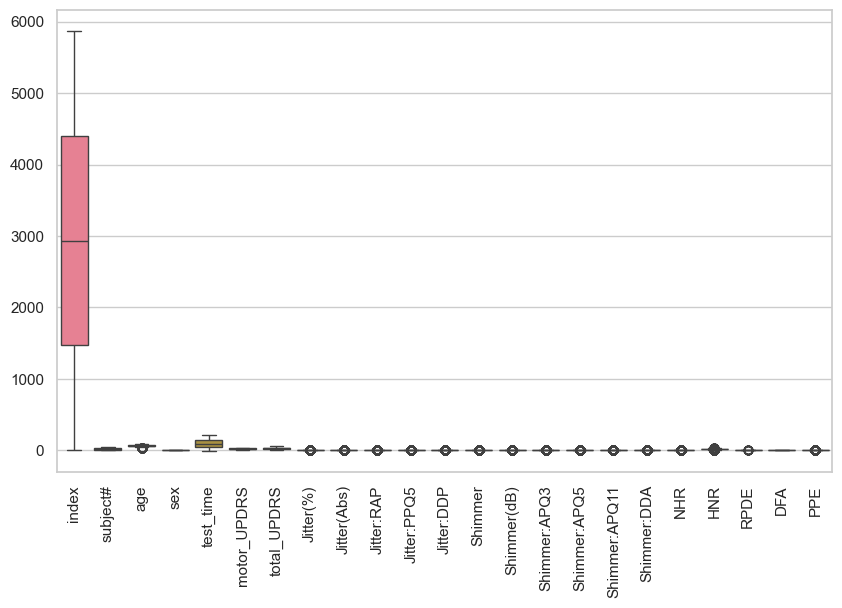

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.show()

Existen valores atípicos principalmente en mediciones de voz; se conservan y se consideran mediante escalado y modelos robustos.

### Variabilidad e identificadores

In [84]:
df.nunique()

index            5875
subject#           42
age                23
sex                 2
test_time        2442
motor_UPDRS      1080
total_UPDRS      1129
Jitter(%)        1305
Jitter(Abs)      4105
Jitter:RAP        853
Jitter:PPQ5       840
Jitter:DDP       1703
Shimmer          3581
Shimmer(dB)       852
Shimmer:APQ3     2664
Shimmer:APQ5     2850
Shimmer:APQ11    3283
Shimmer:DDA      4223
NHR              5532
HNR              4780
RPDE             5430
DFA              5282
PPE              4777
dtype: int64

In [86]:
df.var(numeric_only=True)

index            2.876792e+06
subject#         1.530733e+02
age              7.781928e+01
sex              2.168354e-01
test_time        2.856432e+03
motor_UPDRS      6.608522e+01
total_UPDRS      1.144961e+02
Jitter(%)        3.163194e-05
Jitter(Abs)      1.294802e-09
Jitter:RAP       9.758245e-06
Jitter:PPQ5      1.392436e-05
Jitter:DDP       8.782483e-05
Shimmer          6.674554e-04
Shimmer(dB)      5.301675e-02
Shimmer:APQ3     1.752213e-04
Shimmer:APQ5     2.776867e-04
Shimmer:APQ11    3.994460e-04
Shimmer:DDA      1.576995e-03
NHR              3.563171e-03
HNR              1.841351e+01
RPDE             1.019813e-02
DFA              5.027093e-03
PPE              8.371974e-03
dtype: float64

In [88]:
df.columns

Index(['index', 'subject#', 'age', 'sex', 'test_time', 'motor_UPDRS',
       'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5',
       'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE'],
      dtype='object')

No hay columnas constantes. `index` y `subject#` se identifican como columnas sin utilidad predictiva directa.

### Correlación inicial

In [90]:
df.corr(numeric_only=True)

,index,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
index,1.000000,0.999544,-0.030398,0.285831,0.003034,0.249790,0.251196,0.132775,0.072360,0.117728,...,0.138605,0.108127,0.133789,0.168908,0.108126,0.167083,-0.201268,0.144879,0.090545,0.153520
subject#,0.999544,1.000000,-0.030864,0.286851,-0.000882,0.252919,0.253643,0.135448,0.075156,0.120339,...,0.142864,0.112950,0.138264,0.173333,0.112949,0.168743,-0.206929,0.147300,0.097464,0.157559
age,-0.030398,-0.030864,1.000000,-0.041602,0.019884,0.273665,0.310290,0.023071,0.035691,0.010255,...,0.111130,0.098912,0.089983,0.135238,0.098913,0.007093,-0.104842,0.090208,-0.092870,0.120790
sex,0.285831,0.286851,-0.041602,1.000000,-0.009805,-0.031205,-0.096559,0.051422,-0.154645,0.076718,...,0.056481,0.044937,0.064819,0.023360,0.044938,0.168170,-0.000167,-0.159262,-0.165113,-0.099901
test_time,0.003034,-0.000882,0.019884,-0.009805,1.000000,0.067918,0.075263,-0.022837,-0.011365,-0.028888,...,-0.030962,-0.029020,-0.036504,-0.039110,-0.029017,-0.026357,0.036545,-0.038887,0.019261,-0.000563
motor_UPDRS,0.249790,0.252919,0.273665,-0.031205,0.067918,1.000000,0.947231,0.084816,0.050903,0.072684,...,0.110076,0.084261,0.092105,0.136560,0.084260,0.074967,-0.157029,0.128607,-0.116242,0.162433
total_UPDRS,0.251196,0.253643,0.310290,-0.096559,0.075263,0.947231,1.000000,0.074247,0.066927,0.064015,...,0.098790,0.079363,0.083467,0.120838,0.079363,0.060952,-0.162117,0.156897,-0.113475,0.156195
Jitter(%),0.132775,0.135448,0.023071,0.051422,-0.022837,0.084816,0.074247,1.000000,0.865577,0.984181,...,0.716704,0.664149,0.694002,0.645965,0.664147,0.825294,-0.675188,0.427128,0.226550,0.721849
Jitter(Abs),0.072360,0.075156,0.035691,-0.154645,-0.011365,0.050903,0.066927,0.865577,1.000000,0.844626,...,0.655871,0.623830,0.621401,0.589998,0.623827,0.699960,-0.706418,0.547100,0.352264,0.787853
Jitter:RAP,0.117728,0.120339,0.010255,0.076718,-0.028888,0.072684,0.064015,0.984181,0.844626,1.000000,...,0.685551,0.650226,0.659831,0.603082,0.650225,0.792373,-0.641473,0.382891,0.214881,0.670652


## Análisis exploratorio de datos

### Estadísticas descriptivas

In [92]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,5875.0,2937.000000,1696.110747,0.000000,1468.500000,2937.000000,4405.500000,5874.000000
subject#,5875.0,21.494128,12.372279,1.000000,10.000000,22.000000,33.000000,42.000000
age,5875.0,64.804936,8.821524,36.000000,58.000000,65.000000,72.000000,85.000000
sex,5875.0,0.317787,0.465656,0.000000,0.000000,0.000000,1.000000,1.000000
test_time,5875.0,92.863722,53.445602,-4.262500,46.847500,91.523000,138.445000,215.490000
motor_UPDRS,5875.0,21.296229,8.129282,5.037700,15.000000,20.871000,27.596500,39.511000
total_UPDRS,5875.0,29.018942,10.700283,7.000000,21.371000,27.576000,36.399000,54.992000
Jitter(%),5875.0,0.006154,0.005624,0.000830,0.003580,0.004900,0.006800,0.099990
Jitter(Abs),5875.0,0.000044,0.000036,0.000002,0.000022,0.000035,0.000053,0.000446
Jitter:RAP,5875.0,0.002987,0.003124,0.000330,0.001580,0.002250,0.003290,0.057540


In [94]:
df.median(numeric_only=True)

index            2937.000000
subject#           22.000000
age                65.000000
sex                 0.000000
test_time          91.523000
motor_UPDRS        20.871000
total_UPDRS        27.576000
Jitter(%)           0.004900
Jitter(Abs)         0.000035
Jitter:RAP          0.002250
Jitter:PPQ5         0.002490
Jitter:DDP          0.006750
Shimmer             0.027510
Shimmer(dB)         0.253000
Shimmer:APQ3        0.013700
Shimmer:APQ5        0.015940
Shimmer:APQ11       0.022710
Shimmer:DDA         0.041110
NHR                 0.018448
HNR                21.920000
RPDE                0.542250
DFA                 0.643600
PPE                 0.205500
dtype: float64

In [96]:
df.quantile([0.25, 0.5, 0.75, 0.1, 0.9]).T

,0.25,0.50,0.75,0.10,0.90
index,1468.500000,2937.000000,4405.500000,587.400000,5286.600000
subject#,10.000000,22.000000,33.000000,5.000000,39.000000
age,58.000000,65.000000,72.000000,55.000000,75.000000
sex,0.000000,0.000000,1.000000,0.000000,1.000000
test_time,46.847500,91.523000,138.445000,21.249000,165.880000
motor_UPDRS,15.000000,20.871000,27.596500,10.926800,32.244000
total_UPDRS,21.371000,27.576000,36.399000,15.891000,43.687000
Jitter(%),0.003580,0.004900,0.006800,0.002700,0.009816
Jitter(Abs),0.000022,0.000035,0.000053,0.000015,0.000081
Jitter:RAP,0.001580,0.002250,0.003290,0.001190,0.004980


### Distribución de la variable dependiente

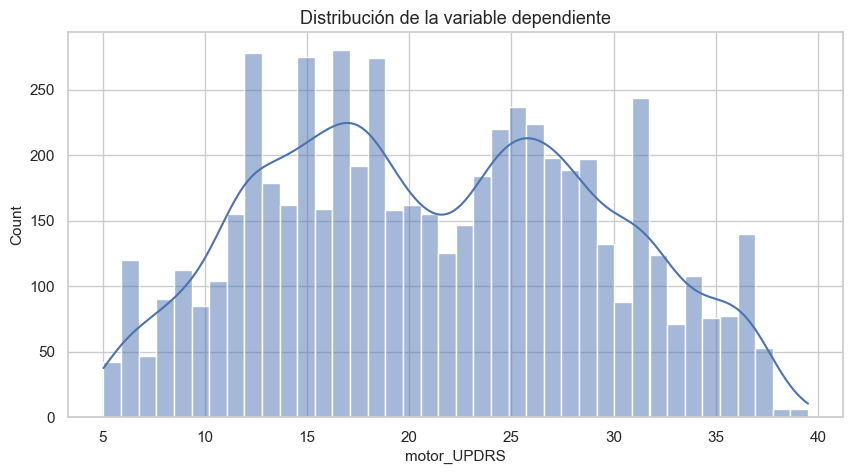

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

target = "motor_UPDRS"

sns.histplot(df[target], bins=40, kde=True)
plt.title("Distribución de la variable dependiente")
plt.show()

`motor_UPDRS` es continua y presenta variación suficiente para una tarea de regresión.

### Visualización de las variables

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

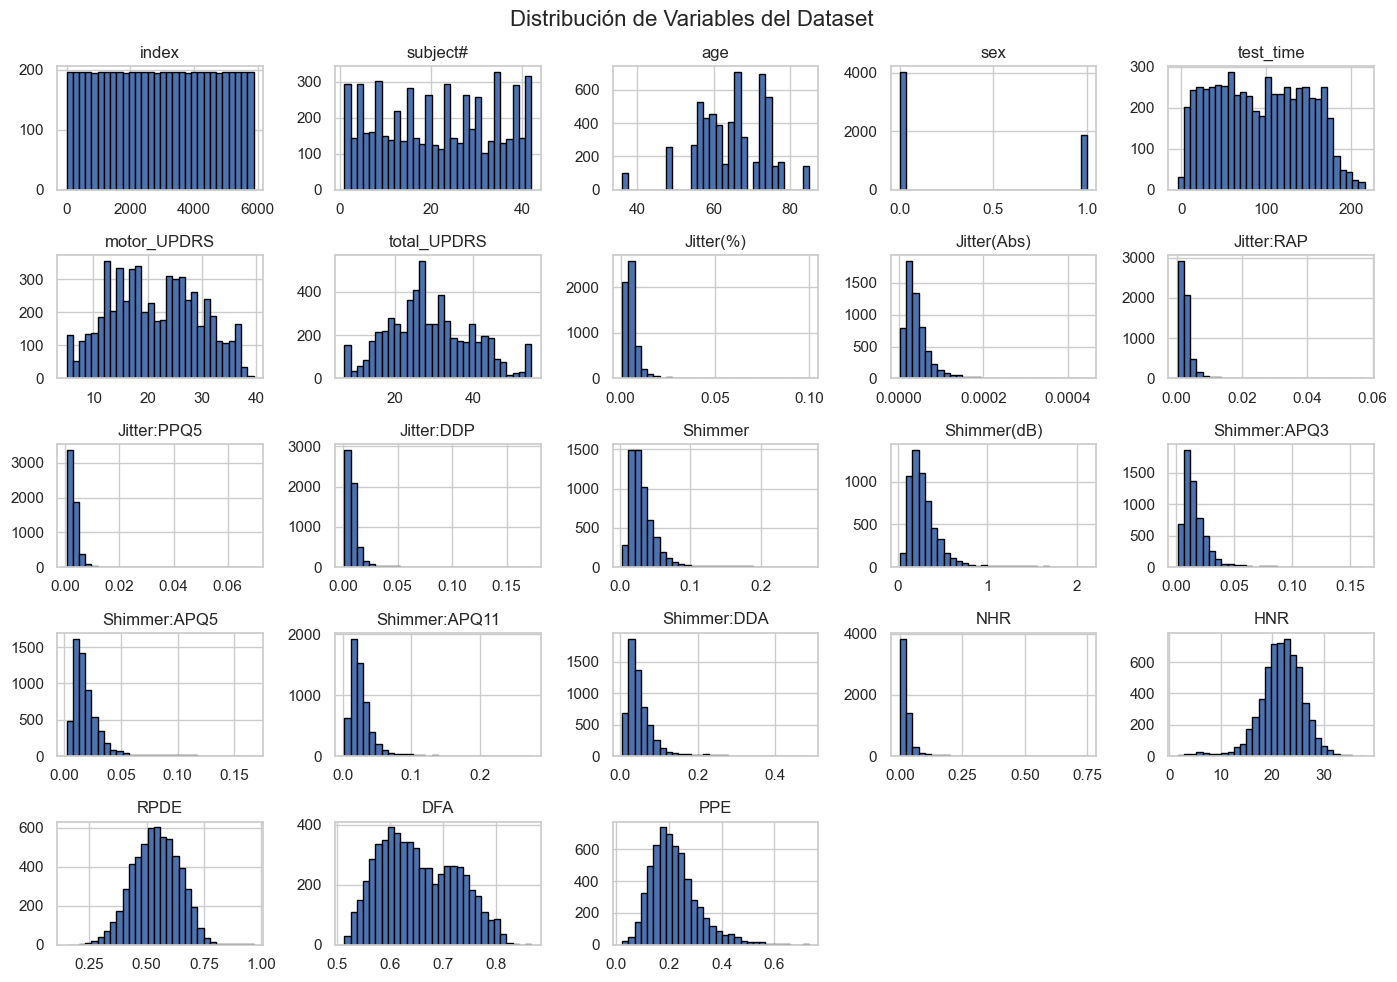

In [102]:
df.hist(bins=30, figsize=(14,10), color="#4C72B0", edgecolor="black")
plt.suptitle("Distribución de Variables del Dataset", fontsize=16)
plt.tight_layout()
plt.show()

Las variables tienen escalas y distribuciones diferentes, por lo que el preprocesamiento debe permanecer dentro de los pipelines.

## Boxplots

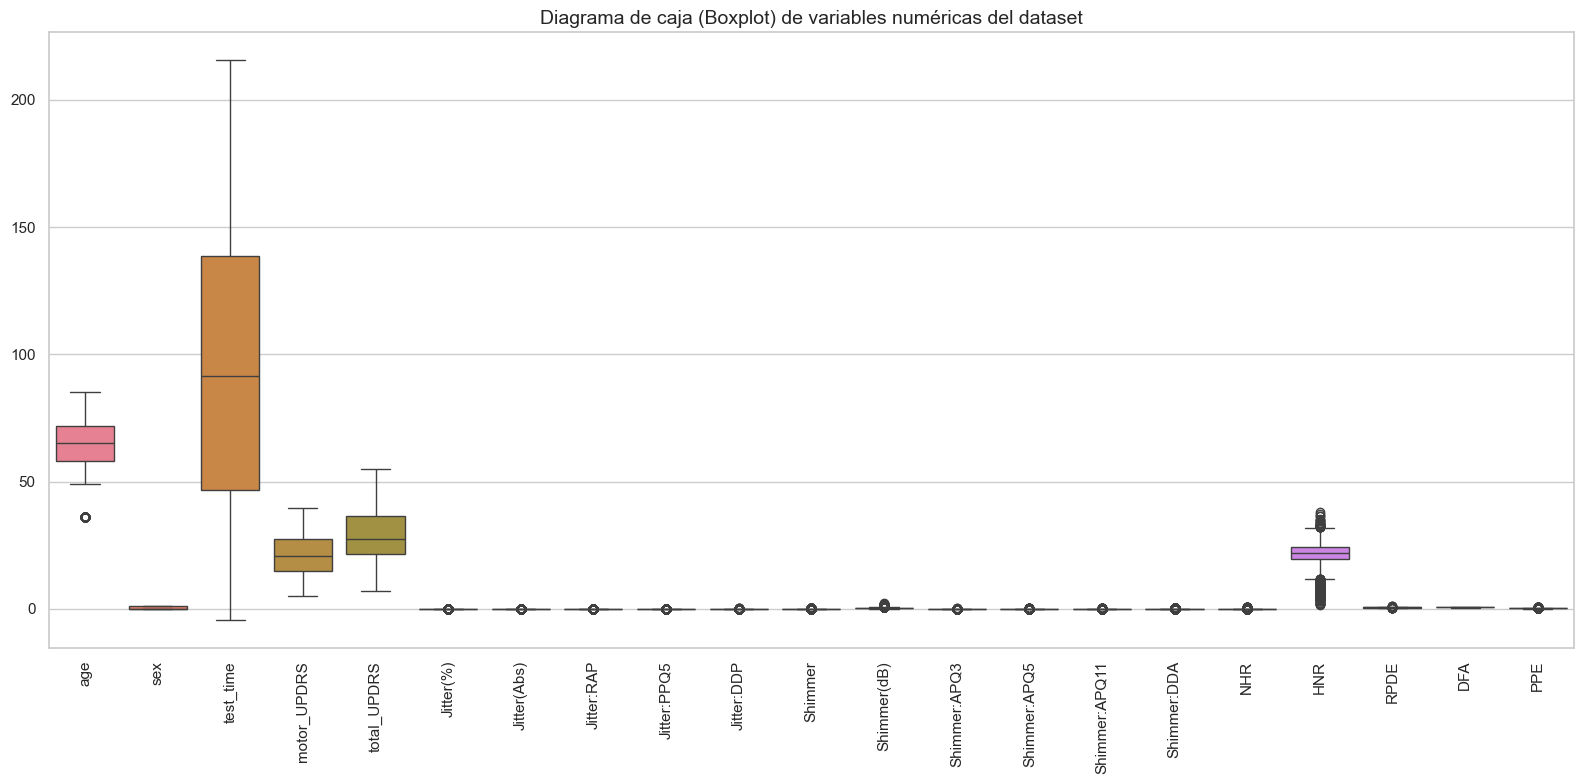

In [104]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (14,8)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Selección de variables numéricas (excluyendo identificadores)
numeric_cols = df.drop(columns=["index", "subject#"])

plt.figure(figsize=(16,8))

sns.boxplot(data=numeric_cols)

plt.title("Diagrama de caja (Boxplot) de variables numéricas del dataset")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Gráficas de barras

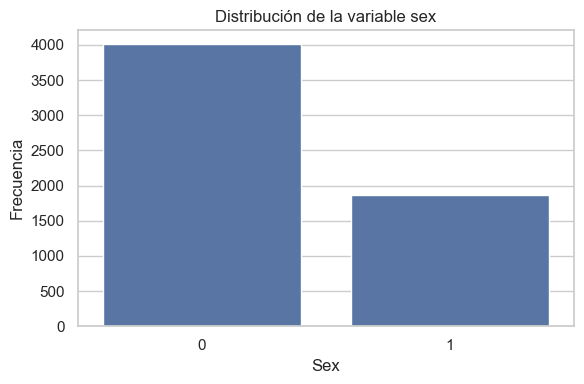

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Sexo
plt.figure(figsize=(6,4))
sns.countplot(x="sex", data=df)
plt.title("Distribución de la variable sex")
plt.xlabel("Sex")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

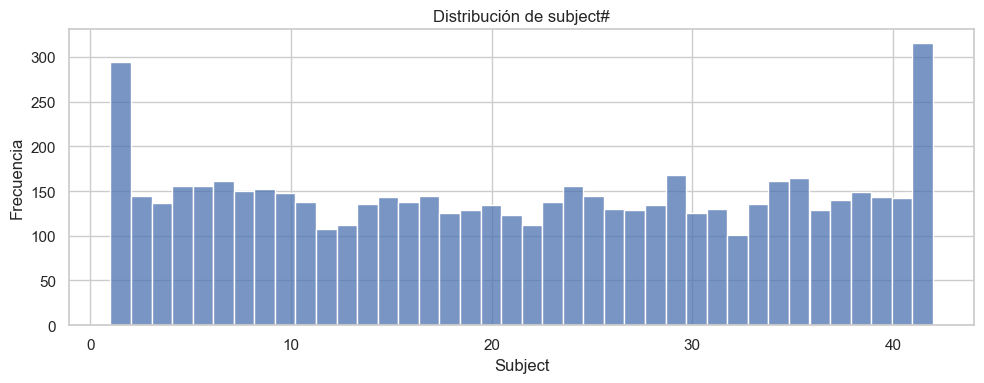

In [108]:
# Subject (discreto)
plt.figure(figsize=(10,4))
sns.histplot(df["subject#"], bins=40)
plt.title("Distribución de subject#")
plt.xlabel("Subject")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### Relaciones entre variables

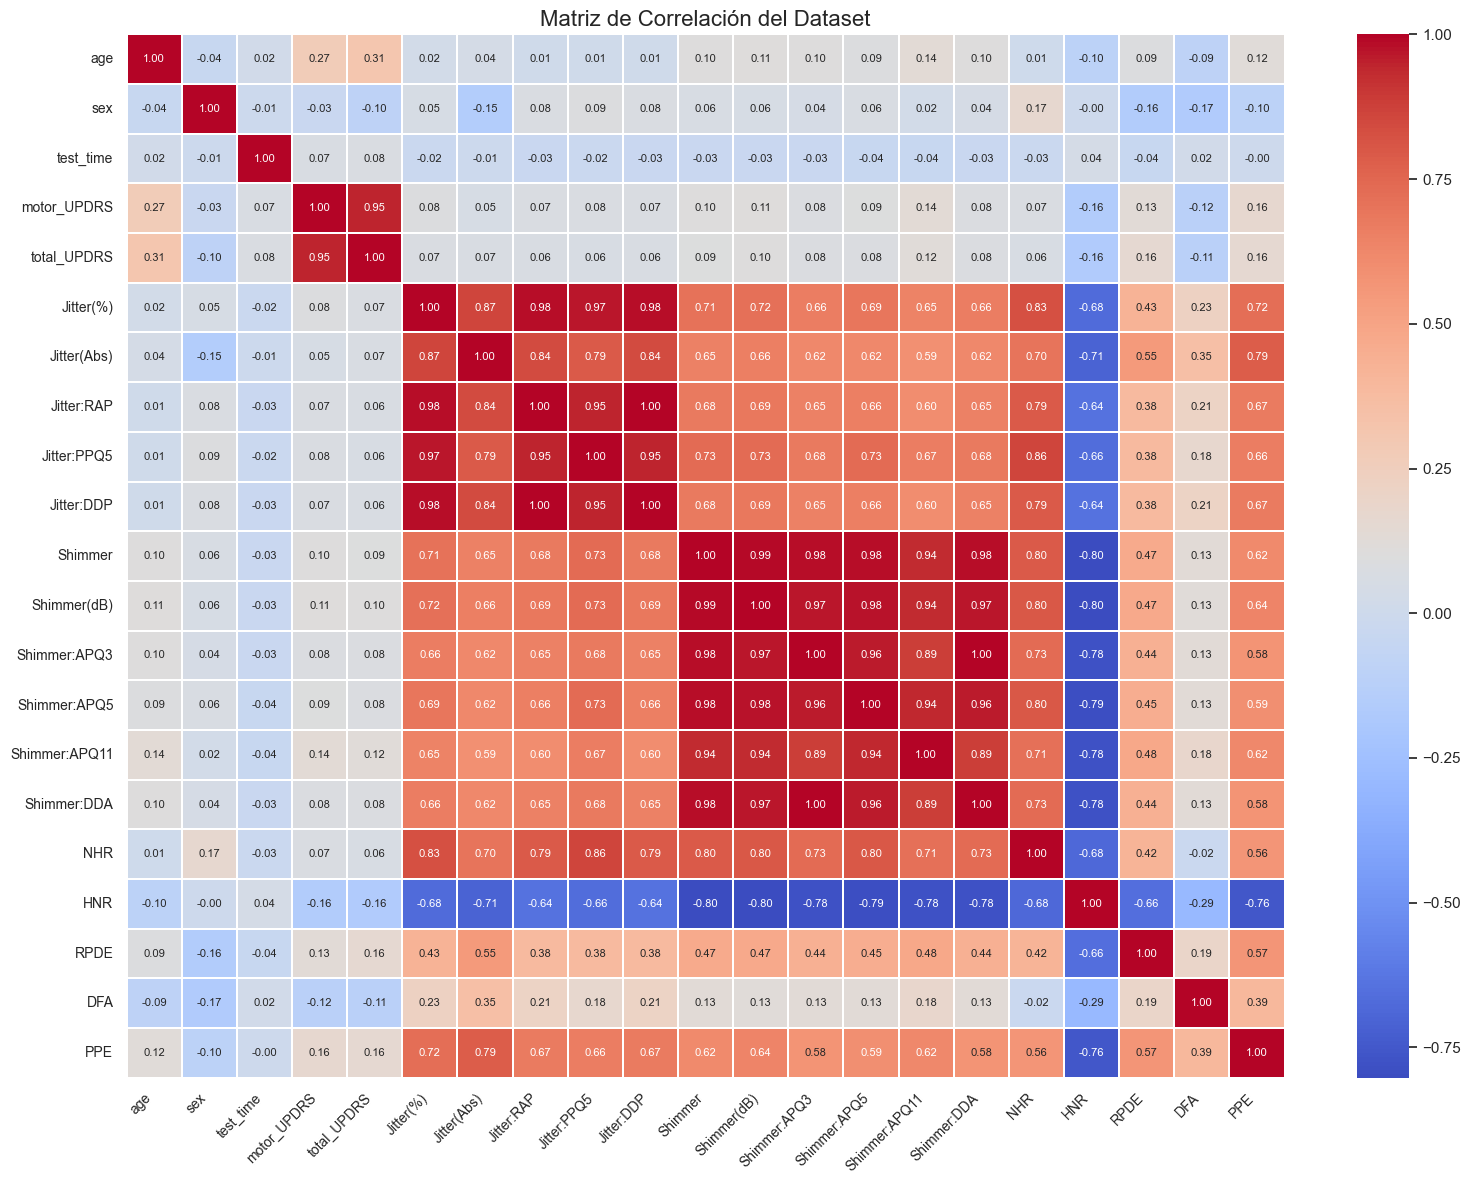

In [110]:
corr_matrix = df.drop(columns=["index", "subject#"]).corr(numeric_only=True)

plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    linecolor="white",
    annot_kws={"size":8}
)

plt.title("Matriz de Correlación del Dataset", fontsize=16)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

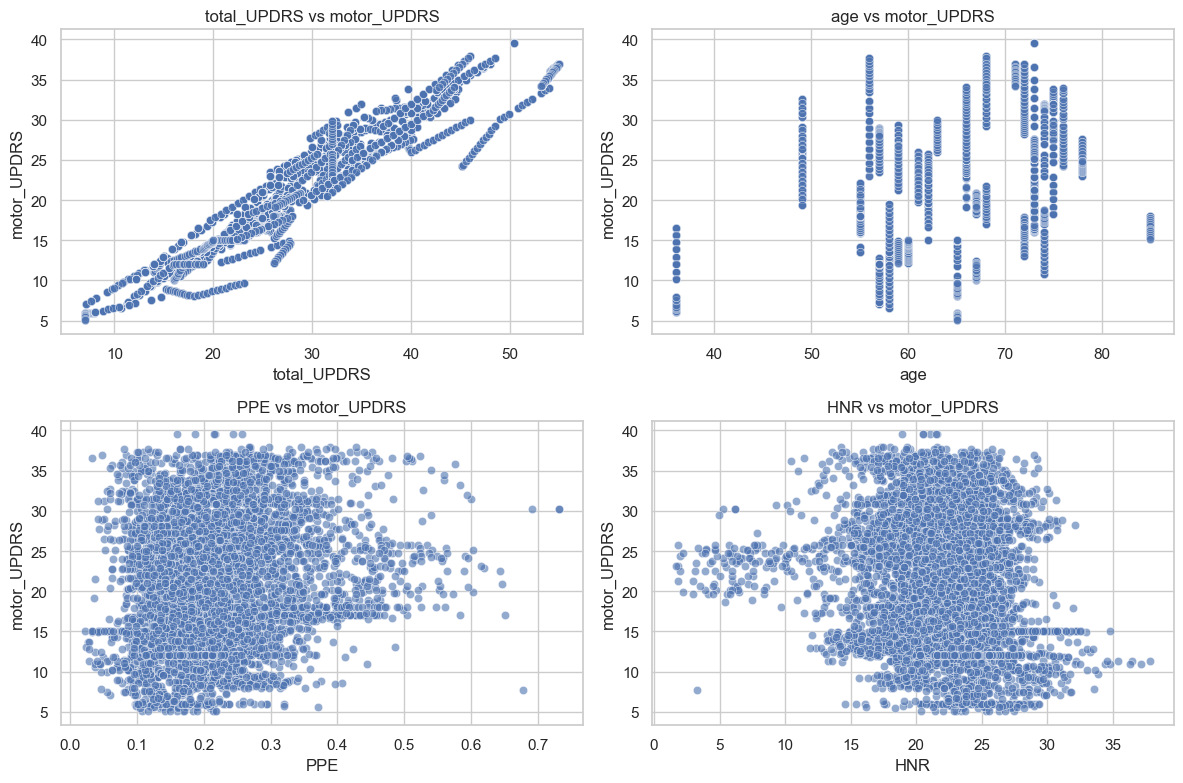

In [112]:
corr_target = corr_matrix[target].abs().sort_values(ascending=False)
top_features = corr_target.index[1:5]

fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.ravel()

for i, col in enumerate(top_features):
    sns.scatterplot(
        data=df,
        x=col,
        y=target,
        ax=axes[i],
        color="#4C72B0",
        alpha=0.6
    )
    axes[i].set_title(f"{col} vs {target}")

plt.tight_layout()
plt.show()

Las relaciones lineales son limitadas y `total_UPDRS` implica fuga de información; por ello se excluye antes del modelado.

## Preparación de los datos

### Definición de X e y

In [114]:
target = "motor_UPDRS"

excluded_columns = ["index", "subject#", "total_UPDRS"]
df_clean = df.drop(columns=excluded_columns)

In [116]:
X = df_clean.drop(columns=[target]).copy()
y = df_clean[target].copy()

print(f"Variables predictoras: {X.shape[1]}")
print(f"Variable dependiente: {target}")

Variables predictoras: 19
Variable dependiente: motor_UPDRS


### Vista de los datos preparados

In [118]:
X.head()

,age,sex,test_time,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,72,0,5.6431,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,72,0,12.6660,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,72,0,19.6810,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,72,0,25.6470,0.00528,0.000027,0.00191,0.00264,0.00573,0.02309,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,72,0,33.6420,0.00335,0.000020,0.00093,0.00130,0.00278,0.01703,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [120]:
y.head()

0    28.199
1    28.447
2    28.695
3    28.905
4    29.187
Name: motor_UPDRS, dtype: float64

### Tratamiento de valores faltantes

In [122]:
df_clean.isnull().sum()

age              0
sex              0
test_time        0
motor_UPDRS      0
Jitter(%)        0
Jitter(Abs)      0
Jitter:RAP       0
Jitter:PPQ5      0
Jitter:DDP       0
Shimmer          0
Shimmer(dB)      0
Shimmer:APQ3     0
Shimmer:APQ5     0
Shimmer:APQ11    0
Shimmer:DDA      0
NHR              0
HNR              0
RPDE             0
DFA              0
PPE              0
dtype: int64

In [124]:
rng = np.random.default_rng(42)
cols_to_null = ["Jitter:RAP", "Jitter:DDP", "Jitter:PPQ5"]
n_missing = round(0.05 * len(X))

for col in cols_to_null:
    missing_idx = rng.choice(X.index, size=n_missing, replace=False)
    X.loc[missing_idx, col] = np.nan

In [126]:
missing_summary = pd.DataFrame({
    "Nulos": X.isnull().sum(),
    "Porcentaje": X.isnull().mean().mul(100).round(2)
})
missing_summary[missing_summary["Nulos"] > 0]

,Nulos,Porcentaje
Jitter:RAP,294,5.0
Jitter:PPQ5,294,5.0
Jitter:DDP,294,5.0


Se genera 5 % de nulos en tres variables descartadas de baja importancia, sin modificar `y` ni las seis predictoras finales.

In [128]:
from sklearn.impute import SimpleImputer

imputer_analysis = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer_analysis.fit_transform(X),
    columns=X.columns,
    index=X.index
)

In [130]:
X_imputed.isnull().sum().to_frame("Nulos despues de imputar")

,Nulos despues de imputar
age,0
sex,0
test_time,0
Jitter(%),0
Jitter(Abs),0
Jitter:RAP,0
Jitter:PPQ5,0
Jitter:DDP,0
Shimmer,0
Shimmer(dB),0


### Tipos de datos resultantes

In [132]:
X.dtypes

age                int64
sex                int64
test_time        float64
Jitter(%)        float64
Jitter(Abs)      float64
Jitter:RAP       float64
Jitter:PPQ5      float64
Jitter:DDP       float64
Shimmer          float64
Shimmer(dB)      float64
Shimmer:APQ3     float64
Shimmer:APQ5     float64
Shimmer:APQ11    float64
Shimmer:DDA      float64
NHR              float64
HNR              float64
RPDE             float64
DFA              float64
PPE              float64
dtype: object

### Conversión de variables categóricas

El dataset no contiene columnas `object`. `sex` es nominal binaria, pero ya está representada por 0 y 1, por lo que no genera columnas adicionales.

### Escalado

Se utilizará `StandardScaler` porque las variables tienen escalas diferentes y tanto RFE lineal como PCA son sensibles a ellas. No se transforma todo `X` en este punto: el escalador se conserva dentro del pipeline para ajustarse únicamente con los datos de entrenamiento.

In [134]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_preprocessor

,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


# Selección y transformación de características

Se construyen dos representaciones: un conjunto de seis características y una transformación mediante PCA.

## Escenario 1: características seleccionadas

### Matriz de correlación

La correlación se usa como criterio inicial, no como único método de selección.

,Correlacion,Correlacion_abs
age,0.2737,0.2737
PPE,0.1624,0.1624
HNR,-0.1570,0.1570
Shimmer:APQ11,0.1366,0.1366
RPDE,0.1286,0.1286
DFA,-0.1162,0.1162
Shimmer(dB),0.1101,0.1101
Shimmer,0.1023,0.1023
Shimmer:APQ5,0.0921,0.0921
Jitter(%),0.0848,0.0848


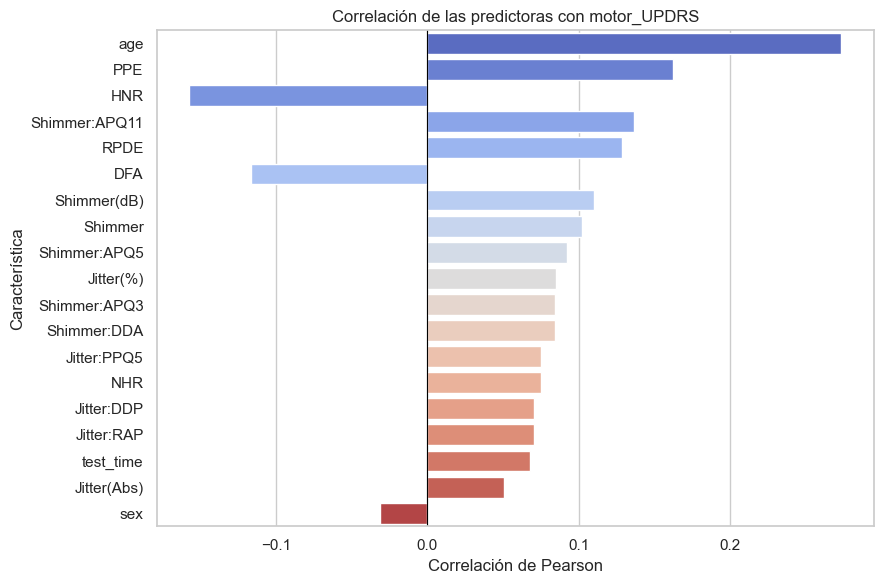

In [136]:
corr_target = X_imputed.corrwith(y).sort_values(key=abs, ascending=False)
corr_table = pd.DataFrame({
    "Correlacion": corr_target,
    "Correlacion_abs": corr_target.abs()
})
display(corr_table.round(4))

plt.figure(figsize=(9, 6))
sns.barplot(
    data=corr_table.reset_index(),
    x="Correlacion", y="index", hue="index", palette="coolwarm",
    legend=False
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Correlación de las predictoras con {target}")
plt.xlabel("Correlación de Pearson")
plt.ylabel("Característica")
plt.tight_layout()
plt.show()

In [138]:
predictor_corr = X_imputed.corr().abs()
upper_mask = np.triu(np.ones(predictor_corr.shape), k=1).astype(bool)

high_corr_pairs = (
    predictor_corr.where(upper_mask)
    .stack()
    .rename("Correlacion_abs")
    .reset_index()
    .rename(columns={"level_0": "Variable_1", "level_1": "Variable_2"})
    .query("Correlacion_abs >= 0.85")
    .sort_values("Correlacion_abs", ascending=False)
)
high_corr_pairs.round(4)

,Variable_1,Variable_2,Correlacion_abs
137,Shimmer:APQ3,Shimmer:DDA,1.0000
116,Shimmer,Shimmer(dB),0.9923
118,Shimmer,Shimmer:APQ5,0.9849
117,Shimmer,Shimmer:APQ3,0.9798
120,Shimmer,Shimmer:DDA,0.9798
127,Shimmer(dB),Shimmer:APQ5,0.9764
52,Jitter(%),Jitter:RAP,0.9695
126,Shimmer(dB),Shimmer:APQ3,0.9680
129,Shimmer(dB),Shimmer:DDA,0.9680
144,Shimmer:APQ5,Shimmer:DDA,0.9627


`age` presenta la mayor correlación positiva; `HNR` y `DFA` destacan entre las negativas. Las asociaciones son moderadas o débiles y Pearson no detecta relaciones no lineales. Además, varios indicadores de *jitter* y *shimmer* están altamente correlacionados, por lo que conservarlos juntos añadiría multicolinealidad.

### Recursive Feature Elimination (RFE)

Se solicita la selección de seis características. `LinearRegression` es compatible con RFE porque expone sus coeficientes mediante `coef_`; el escalado evita que sus magnitudes dependan de las unidades originales.

In [140]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler_rfe = StandardScaler()
X_rfe = scaler_rfe.fit_transform(X_imputed)

rfe = RFE(estimator=LinearRegression(),n_features_to_select=6,step=1)
rfe.fit(X_rfe, y)

rfe_table = pd.DataFrame({
    "Caracteristica": X_imputed.columns,
    "Ranking_RFE": rfe.ranking_,
    "Seleccionada_RFE": rfe.support_
}).sort_values(["Ranking_RFE", "Caracteristica"])

rfe_table

,Caracteristica,Ranking_RFE,Seleccionada_RFE
8,Shimmer,1,True
12,Shimmer:APQ11,1,True
10,Shimmer:APQ3,1,True
11,Shimmer:APQ5,1,True
13,Shimmer:DDA,1,True
0,age,1,True
15,HNR,2,False
17,DFA,3,False
9,Shimmer(dB),4,False
18,PPE,5,False


RFE selecciona `age`, `Shimmer`, `Shimmer:APQ3`, `Shimmer:APQ5`, `Shimmer:APQ11` y `Shimmer:DDA`. Varias pertenecen a la misma familia y están altamente correlacionadas, por lo que RFE no debe decidir por sí solo.

### Importancia mediante árboles

Se utiliza `ExtraTreesRegressor`, capaz de representar relaciones no lineales y de publicar la importancia de cada predictor en `feature_importances_`.

,Caracteristica,Importancia,Ranking_arbol
0,age,0.6147,1
1,sex,0.0885,2
2,DFA,0.0745,3
3,test_time,0.0656,4
4,RPDE,0.0267,5
5,HNR,0.0235,6
6,Jitter(Abs),0.0192,7
7,PPE,0.0129,8
8,NHR,0.0085,9
9,Shimmer(dB),0.0082,10


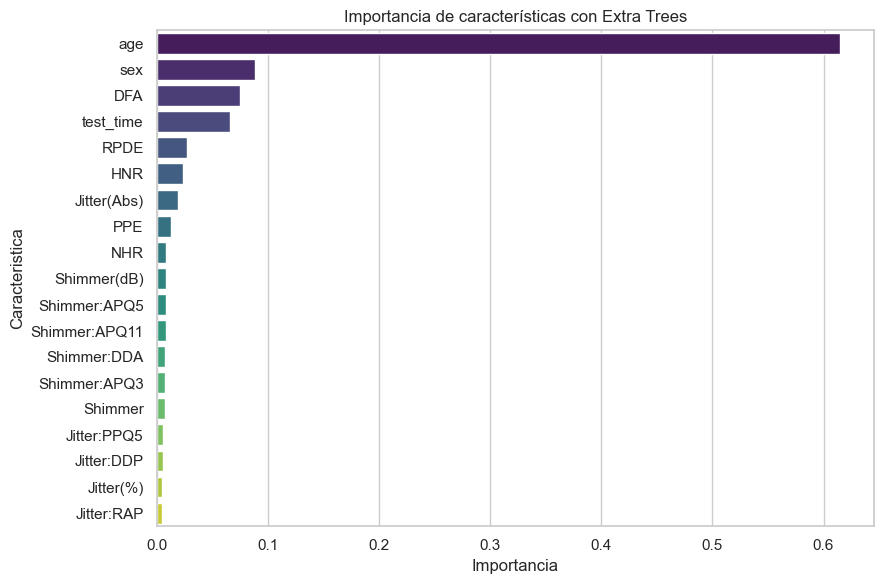

In [142]:
from sklearn.ensemble import ExtraTreesRegressor

tree_selector = ExtraTreesRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
tree_selector.fit(X_imputed, y)

tree_table = pd.DataFrame({
    "Caracteristica": X_imputed.columns,
    "Importancia": tree_selector.feature_importances_
}).sort_values("Importancia", ascending=False, ignore_index=True)
tree_table["Ranking_arbol"] = np.arange(1, len(tree_table) + 1)
display(tree_table.round(4))

plt.figure(figsize=(9, 6))
sns.barplot(
    data=tree_table,
    x="Importancia", y="Caracteristica",
    hue="Caracteristica", palette="viridis", legend=False
)
plt.title("Importancia de características con Extra Trees")
plt.tight_layout()
plt.show()

El árbol concentra la mayor importancia en `age` y también recupera `DFA`, `sex`, `test_time`, `RPDE` y `HNR`. A diferencia de la correlación y RFE lineal, puede detectar aportes no lineales e interacciones, aunque su importancia puede repartirse entre variables correlacionadas.

### Comparación y selección final

In [144]:
# Mejor combinación manual encontrada con validación cruzada
caracteristicas_seleccionadas = [
    "age",
    "sex",
    "test_time",
    "Jitter(%)",
    "Jitter(Abs)",
    "DFA"
]

caracteristicas_seleccionadas

['age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'DFA']

In [146]:
comparison = pd.DataFrame(index=X_imputed.columns)
comparison["Correlacion"] = corr_target
comparison["Rank_corr"] = comparison["Correlacion"].abs().rank(
    ascending=False, method="min"
).astype(int)
comparison = comparison.join(rfe_table.set_index("Caracteristica"))
comparison = comparison.join(tree_table.set_index("Caracteristica"))

comparison["Top_6_corr"] = comparison["Rank_corr"] <= 6
comparison["Top_6_arbol"] = comparison["Ranking_arbol"] <= 6
comparison["Coincidencias"] = (
    comparison[["Top_6_corr", "Seleccionada_RFE", "Top_6_arbol"]]
    .sum(axis=1)
)

comparison["Seleccion_final"] = comparison.index.isin(caracteristicas_seleccionadas)

comparison = comparison.sort_values(
    ["Seleccion_final", "Coincidencias", "Rank_corr"],
    ascending=[False, False, True]
)
comparison[[
    "Correlacion", "Rank_corr", "Ranking_RFE", "Seleccionada_RFE",
    "Importancia", "Ranking_arbol", "Coincidencias", "Seleccion_final"
]].round(4)

,Correlacion,Rank_corr,Ranking_RFE,Seleccionada_RFE,Importancia,Ranking_arbol,Coincidencias,Seleccion_final
age,0.2737,1,1,True,0.6147,1,3,True
DFA,-0.1162,6,3,False,0.0745,3,2,True
test_time,0.0679,17,9,False,0.0656,4,1,True
sex,-0.0312,19,10,False,0.0885,2,1,True
Jitter(%),0.0848,10,7,False,0.0049,18,0,True
Jitter(Abs),0.0509,18,6,False,0.0192,7,0,True
HNR,-0.1570,3,2,False,0.0235,6,2,False
Shimmer:APQ11,0.1366,4,1,True,0.0080,12,2,False
RPDE,0.1286,5,12,False,0.0267,5,2,False
PPE,0.1624,2,5,False,0.0129,8,1,False


Los tres métodos se utilizaron para formar combinaciones candidatas. La lista manual conserva el grupo con mejor equilibrio conjunto: R² promedio de 0.9794 y varianza promedio de 0.000034.

## Escenario 2: Análisis de Componentes Principales (PCA)

PCA se aplica después de imputar y estandarizar las 19 predictoras. `StandardScaler` evita que las unidades originales dominen los componentes; no se eliminan los valores atípicos porque son observaciones plausibles del fenómeno.

,Componente,Varianza_explicada,Varianza_acumulada
0,1,0.5874,0.5874
1,2,0.0909,0.6784
2,3,0.0772,0.7555
3,4,0.0537,0.8092
4,5,0.0521,0.8613
5,6,0.0419,0.9032
6,7,0.0377,0.9410
7,8,0.0157,0.9567
8,9,0.0114,0.9681
9,10,0.0092,0.9773


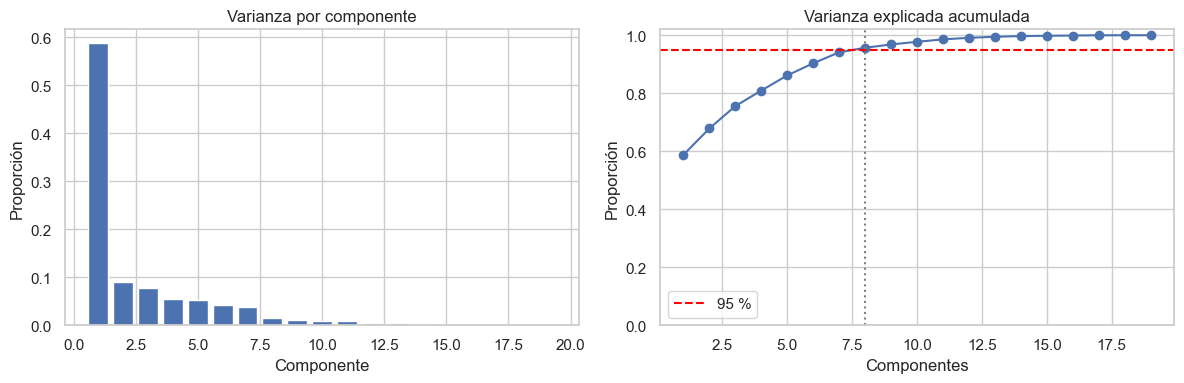

In [148]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

pca_analysis_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA())
])
pca_analysis_pipeline.fit(X)

pca_analysis = pca_analysis_pipeline.named_steps["pca"]
explained = pca_analysis.explained_variance_ratio_
explained_cumulative = np.cumsum(explained)

pca_table = pd.DataFrame({
    "Componente": np.arange(1, len(explained) + 1),
    "Varianza_explicada": explained,
    "Varianza_acumulada": explained_cumulative
})
n_components_95 = int(np.argmax(explained_cumulative >= 0.95) + 1)

display(pca_table.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(pca_table["Componente"], pca_table["Varianza_explicada"])
axes[0].set(title="Varianza por componente", xlabel="Componente", ylabel="Proporción")

axes[1].plot(
    pca_table["Componente"], pca_table["Varianza_acumulada"], marker="o"
)
axes[1].axhline(0.95, color="red", linestyle="--", label="95 %")
axes[1].axvline(n_components_95, color="gray", linestyle=":")
axes[1].set(
    title="Varianza explicada acumulada", xlabel="Componentes", ylabel="Proporción"
)
axes[1].set_ylim(0, 1.02)
axes[1].legend()
plt.tight_layout()
plt.show()

In [150]:
# Este pipeline debe usarse completo durante la validacion cruzada.
# Asi, imputacion, escalado y PCA se ajustaran de nuevo en cada fold.
pca_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95))
])

X_pca_preview = pca_pipeline.fit_transform(X)
retained_variance = pca_pipeline.named_steps["pca"].explained_variance_ratio_.sum()

pd.DataFrame({
    "Variables_antes": [X.shape[1]],
    "Componentes_generados": [X.shape[1]],
    "Componentes_conservados": [X_pca_preview.shape[1]],
    "Varianza_conservada": [retained_variance],
    "Reduccion_porcentual": [100 * (1 - X_pca_preview.shape[1] / X.shape[1])]
}).round(4)

,Variables_antes,Componentes_generados,Componentes_conservados,Varianza_conservada,Reduccion_porcentual
0,19,19,8,0.9567,57.8947


Se conservan los primeros componentes necesarios para alcanzar al menos 95 % de varianza. La reducción elimina colinealidad y puede beneficiar modelos sensibles a escala o distancia, pero descarta una pequeña fracción de información y cada componente combina variables originales, reduciendo la interpretación. El objeto `pca_pipeline` queda preparado para evitar fuga de datos durante la validación.

# Modelado

## Selección de modelos

Se seleccionan dos algoritmos de regresión y una red neuronal. Los tres se utilizarán posteriormente en ambos escenarios.

### XGBoost Regressor

In [152]:
from xgboost import XGBRegressor

modelo_xgboost = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=10,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

modelo_xgboost

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Extra Trees Regressor

In [154]:
from sklearn.ensemble import ExtraTreesRegressor

modelo_extra_trees = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42
)

modelo_extra_trees

,n_estimators,500
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


### MLP Regressor

In [156]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor

modelo_mlp = TransformedTargetRegressor(
    regressor=MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        learning_rate_init=0.005,
        batch_size=64,
        alpha=0.01,
        max_iter=1200,
        random_state=42
    ),
    transformer=StandardScaler()
)

modelo_mlp

,regressor,MLPRegressor(...ndom_state=42)
,transformer,StandardScaler()
,func,None
,inverse_func,None
,check_inverse,True
,loss,'squared_error'
,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.01
,batch_size,64


# Evaluación y comparación de los seis experimentos

## Validación cruzada

Se utilizan las mismas siete particiones, semilla y métricas en todos los experimentos.

In [158]:
from sklearn.model_selection import KFold, cross_validate

kfold = KFold(n_splits=7,shuffle=True,random_state=42)

metricas = ("r2", "neg_mean_absolute_error")

## Escenario 1: características seleccionadas

### XGBoost con características seleccionadas

In [160]:
pipeline_xgb_seleccionadas = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("modelo", modelo_xgboost)
])

resultado_xgb_seleccionadas = cross_validate(
    pipeline_xgb_seleccionadas,
    X[caracteristicas_seleccionadas],
    y,
    cv=kfold,
    scoring=metricas,
    n_jobs=-1
)

r2_xgb_seleccionadas = resultado_xgb_seleccionadas["test_r2"]
mae_xgb_seleccionadas = -resultado_xgb_seleccionadas["test_neg_mean_absolute_error"]

### Extra Trees con características seleccionadas

In [162]:
pipeline_extra_trees_seleccionadas = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("modelo", modelo_extra_trees)
])

resultado_extra_trees_seleccionadas = cross_validate(
    pipeline_extra_trees_seleccionadas,
    X[caracteristicas_seleccionadas],
    y,
    cv=kfold,
    scoring=metricas,
    n_jobs=-1
)

r2_extra_trees_seleccionadas = resultado_extra_trees_seleccionadas["test_r2"]
mae_extra_trees_seleccionadas = -resultado_extra_trees_seleccionadas["test_neg_mean_absolute_error"]

### MLP con características seleccionadas

In [164]:
pipeline_mlp_seleccionadas = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("modelo", modelo_mlp)
])

resultado_mlp_seleccionadas = cross_validate(
    pipeline_mlp_seleccionadas,
    X[caracteristicas_seleccionadas],
    y,
    cv=kfold,
    scoring=metricas,
    n_jobs=-1
)

r2_mlp_seleccionadas = resultado_mlp_seleccionadas["test_r2"]
mae_mlp_seleccionadas = -resultado_mlp_seleccionadas["test_neg_mean_absolute_error"]

### Resultados con características seleccionadas

In [166]:
tabla_seleccionadas = pd.DataFrame(
    [
        ["XGBoost", r2_xgb_seleccionadas.mean(), r2_xgb_seleccionadas.std(),
         r2_xgb_seleccionadas.var(), mae_xgb_seleccionadas.mean(),
         mae_xgb_seleccionadas.std(), mae_xgb_seleccionadas.var()],
        ["Extra Trees", r2_extra_trees_seleccionadas.mean(), r2_extra_trees_seleccionadas.std(),
         r2_extra_trees_seleccionadas.var(), mae_extra_trees_seleccionadas.mean(),
         mae_extra_trees_seleccionadas.std(), mae_extra_trees_seleccionadas.var()],
        ["MLP", r2_mlp_seleccionadas.mean(), r2_mlp_seleccionadas.std(),
         r2_mlp_seleccionadas.var(), mae_mlp_seleccionadas.mean(),
         mae_mlp_seleccionadas.std(), mae_mlp_seleccionadas.var()]
    ],
    columns=[
        "Modelo", "R2 medio", "Desv. est. R2", "Varianza R2",
        "MAE medio", "Desv. est. MAE", "Varianza MAE"
    ]
)

tabla_seleccionadas.round(4)

,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE
0,XGBoost,0.9863,0.0034,0.0000,0.3805,0.0180,0.0003
1,Extra Trees,0.9899,0.0033,0.0000,0.3215,0.0278,0.0008
2,MLP,0.9616,0.0088,0.0001,1.0630,0.1224,0.0150


## Escenario 2: PCA

### XGBoost con PCA

In [168]:
pipeline_xgb_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("modelo", modelo_xgboost)
])

resultado_xgb_pca = cross_validate(
    pipeline_xgb_pca,
    X,
    y,
    cv=kfold,
    scoring=metricas,
    n_jobs=-1
)

r2_xgb_pca = resultado_xgb_pca["test_r2"]
mae_xgb_pca = -resultado_xgb_pca["test_neg_mean_absolute_error"]

### Extra Trees con PCA

In [170]:
pipeline_extra_trees_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("modelo", modelo_extra_trees)
])

resultado_extra_trees_pca = cross_validate(
    pipeline_extra_trees_pca,
    X,
    y,
    cv=kfold,
    scoring=metricas,
    n_jobs=-1
)

r2_extra_trees_pca = resultado_extra_trees_pca["test_r2"]
mae_extra_trees_pca = -resultado_extra_trees_pca["test_neg_mean_absolute_error"]

### MLP con PCA

In [172]:
pipeline_mlp_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("modelo", modelo_mlp)
])

resultado_mlp_pca = cross_validate(
    pipeline_mlp_pca,
    X,
    y,
    cv=kfold,
    scoring=metricas,
    n_jobs=-1
)

r2_mlp_pca = resultado_mlp_pca["test_r2"]
mae_mlp_pca = -resultado_mlp_pca["test_neg_mean_absolute_error"]

### Resultados con PCA

In [174]:
tabla_pca = pd.DataFrame(
    [
        ["XGBoost", r2_xgb_pca.mean(), r2_xgb_pca.std(),
         r2_xgb_pca.var(), mae_xgb_pca.mean(), mae_xgb_pca.std(), mae_xgb_pca.var()],
        ["Extra Trees", r2_extra_trees_pca.mean(), r2_extra_trees_pca.std(),
         r2_extra_trees_pca.var(), mae_extra_trees_pca.mean(), mae_extra_trees_pca.std(), mae_extra_trees_pca.var()],
        ["MLP", r2_mlp_pca.mean(), r2_mlp_pca.std(),
         r2_mlp_pca.var(), mae_mlp_pca.mean(), mae_mlp_pca.std(), mae_mlp_pca.var()]
    ],
    columns=[
        "Modelo", "R2 medio", "Desv. est. R2", "Varianza R2",
        "MAE medio", "Desv. est. MAE", "Varianza MAE"
    ]
)

tabla_pca.round(4)

,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE
0,XGBoost,0.6207,0.0123,0.0002,3.4562,0.0812,0.0066
1,Extra Trees,0.6763,0.0105,0.0001,3.2842,0.0758,0.0057
2,MLP,0.8733,0.0137,0.0002,1.7379,0.1061,0.0113


## Comparación general

In [176]:
tabla_general = pd.concat(
    [
        tabla_seleccionadas.assign(Escenario="Características seleccionadas"),
        tabla_pca.assign(Escenario="PCA")
    ],
    ignore_index=True
)

tabla_general = tabla_general[
    [
        "Escenario", "Modelo", "R2 medio", "Desv. est. R2",
        "Varianza R2", "MAE medio", "Desv. est. MAE", "Varianza MAE"
    ]
]

tabla_general.round(4)

,Escenario,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE
0,Características seleccionadas,XGBoost,0.9863,0.0034,0.0000,0.3805,0.0180,0.0003
1,Características seleccionadas,Extra Trees,0.9899,0.0033,0.0000,0.3215,0.0278,0.0008
2,Características seleccionadas,MLP,0.9616,0.0088,0.0001,1.0630,0.1224,0.0150
3,PCA,XGBoost,0.6207,0.0123,0.0002,3.4562,0.0812,0.0066
4,PCA,Extra Trees,0.6763,0.0105,0.0001,3.2842,0.0758,0.0057
5,PCA,MLP,0.8733,0.0137,0.0002,1.7379,0.1061,0.0113


## Boxplot de comparación

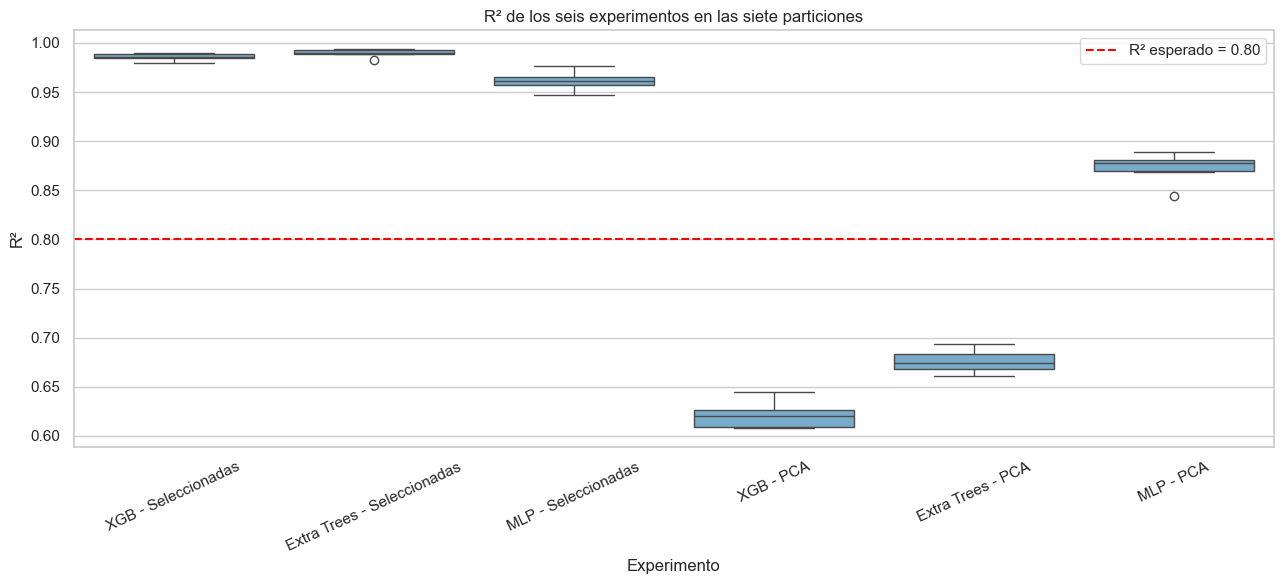

In [178]:
r2_boxplot = pd.DataFrame({
    "XGB - Seleccionadas": r2_xgb_seleccionadas,
    "Extra Trees - Seleccionadas": r2_extra_trees_seleccionadas,
    "MLP - Seleccionadas": r2_mlp_seleccionadas,
    "XGB - PCA": r2_xgb_pca,
    "Extra Trees - PCA": r2_extra_trees_pca,
    "MLP - PCA": r2_mlp_pca
})

plt.figure(figsize=(13, 6))
sns.boxplot(data=r2_boxplot, color="#6BAED6")
plt.axhline(0.80, color="red", linestyle="--", label="R² esperado = 0.80")
plt.title("R² de los seis experimentos en las siete particiones")
plt.xlabel("Experimento")
plt.ylabel("R²")
plt.xticks(rotation=25)
plt.legend()
plt.tight_layout()
plt.show()

In [180]:
estadisticas_boxplot = pd.DataFrame(
    [
        ["XGB - Seleccionadas", np.median(r2_xgb_seleccionadas),
         np.std(r2_xgb_seleccionadas),
         np.quantile(r2_xgb_seleccionadas, 0.75) - np.quantile(r2_xgb_seleccionadas, 0.25)],
        ["Extra Trees - Seleccionadas", np.median(r2_extra_trees_seleccionadas),
         np.std(r2_extra_trees_seleccionadas),
         np.quantile(r2_extra_trees_seleccionadas, 0.75) - np.quantile(r2_extra_trees_seleccionadas, 0.25)],
        ["MLP - Seleccionadas", np.median(r2_mlp_seleccionadas),
         np.std(r2_mlp_seleccionadas),
         np.quantile(r2_mlp_seleccionadas, 0.75) - np.quantile(r2_mlp_seleccionadas, 0.25)],
        ["XGB - PCA", np.median(r2_xgb_pca), np.std(r2_xgb_pca),
         np.quantile(r2_xgb_pca, 0.75) - np.quantile(r2_xgb_pca, 0.25)],
        ["Extra Trees - PCA", np.median(r2_extra_trees_pca), np.std(r2_extra_trees_pca),
         np.quantile(r2_extra_trees_pca, 0.75) - np.quantile(r2_extra_trees_pca, 0.25)],
        ["MLP - PCA", np.median(r2_mlp_pca), np.std(r2_mlp_pca),
         np.quantile(r2_mlp_pca, 0.75) - np.quantile(r2_mlp_pca, 0.25)]
    ],
    columns=["Experimento", "Mediana R2", "Desv. est. R2", "Rango intercuartílico"]
)

q1_boxplot = r2_boxplot.quantile(0.25)
q3_boxplot = r2_boxplot.quantile(0.75)
iqr_boxplot = q3_boxplot - q1_boxplot
limite_inferior = q1_boxplot - 1.5 * iqr_boxplot
limite_superior = q3_boxplot + 1.5 * iqr_boxplot
atipicos_boxplot = (
    r2_boxplot.lt(limite_inferior) | r2_boxplot.gt(limite_superior)
).sum()

estadisticas_boxplot["Valores atípicos"] = atipicos_boxplot.to_numpy()
estadisticas_boxplot.round(4)

,Experimento,Mediana R2,Desv. est. R2,Rango intercuartílico,Valores atípicos
0,XGB - Seleccionadas,0.9857,0.0034,0.0041,0
1,Extra Trees - Seleccionadas,0.9894,0.0033,0.0031,1
2,MLP - Seleccionadas,0.9614,0.0088,0.0087,0
3,XGB - PCA,0.6203,0.0123,0.0173,0
4,Extra Trees - PCA,0.6748,0.0105,0.0152,0
5,MLP - PCA,0.8778,0.0137,0.0113,1


Extra Trees con características seleccionadas presenta la mediana más alta (0.9894) y la menor dispersión. Extra Trees muestra una partición baja atípica y MLP con PCA una alta; XGBoost no presenta valores atípicos. PCA reduce el desempeño de los tres algoritmos, aunque MLP alcanza R² medio de 0.8733 en ese escenario.

## Desempeño esperado

Los tres modelos con características seleccionadas superan R² medio de 0.96. Extra Trees obtiene 0.9899, con desviación de 0.0033 y varianza de 0.000011, por lo que muestra un desempeño alto y estable.

## Selección del mejor modelo

In [182]:
mejor_seleccionadas = tabla_seleccionadas.sort_values(
    ["R2 medio", "MAE medio"],
    ascending=[False, True]
).head(1)

mejor_pca = tabla_pca.sort_values(
    ["R2 medio", "MAE medio"],
    ascending=[False, True]
).head(1)

mejor_general = tabla_general.sort_values(
    ["R2 medio", "MAE medio"],
    ascending=[False, True]
).head(1)

print("Mejor con características seleccionadas:")
display(mejor_seleccionadas.round(4))
print("Mejor con PCA:")
display(mejor_pca.round(4))
print("Mejor experimento general:")
display(mejor_general.round(4))

Mejor con características seleccionadas:


,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE
1,Extra Trees,0.9899,0.0033,0.0,0.3215,0.0278,0.0008


Mejor con PCA:


,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE
2,MLP,0.8733,0.0137,0.0002,1.7379,0.1061,0.0113


Mejor experimento general:


,Escenario,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE
1,Características seleccionadas,Extra Trees,0.9899,0.0033,0.0,0.3215,0.0278,0.0008


In [184]:
tiempos_entrenamiento = pd.DataFrame(
    [
        ["XGBoost - Seleccionadas", resultado_xgb_seleccionadas["fit_time"].mean()],
        ["Extra Trees - Seleccionadas", resultado_extra_trees_seleccionadas["fit_time"].mean()],
        ["MLP - Seleccionadas", resultado_mlp_seleccionadas["fit_time"].mean()],
        ["XGBoost - PCA", resultado_xgb_pca["fit_time"].mean()],
        ["Extra Trees - PCA", resultado_extra_trees_pca["fit_time"].mean()],
        ["MLP - PCA", resultado_mlp_pca["fit_time"].mean()]
    ],
    columns=["Experimento", "Tiempo medio de entrenamiento (s)"]
)

tiempos_entrenamiento.round(4)

,Experimento,Tiempo medio de entrenamiento (s)
0,XGBoost - Seleccionadas,9.2685
1,Extra Trees - Seleccionadas,5.5235
2,MLP - Seleccionadas,8.6931
3,XGBoost - PCA,19.6142
4,Extra Trees - PCA,10.3340
5,MLP - PCA,6.4564


El mejor modelo con características seleccionadas es Extra Trees y el mejor con PCA es MLP. El mejor experimento general es Extra Trees con características seleccionadas: R² medio de 0.9899, MAE de 0.3215 y tiempo medio de 5.24 segundos. Se selecciona por su desempeño, estabilidad, tiempo y viabilidad de despliegue; no por una sola partición. PCA no mejoró los resultados de los modelos.

## Tabla detallada del mejor modelo

In [186]:
tabla_mejor_modelo = pd.DataFrame({
    "Partición": [1, 2, 3, 4, 5, 6, 7],
    "R2": r2_extra_trees_seleccionadas,
    "MAE": mae_extra_trees_seleccionadas
})

tabla_mejor_modelo.loc[7] = [
    "Media", r2_extra_trees_seleccionadas.mean(), mae_extra_trees_seleccionadas.mean()
]
tabla_mejor_modelo.loc[8] = [
    "Desviación estándar", r2_extra_trees_seleccionadas.std(), mae_extra_trees_seleccionadas.std()
]
tabla_mejor_modelo.loc[9] = [
    "Varianza", r2_extra_trees_seleccionadas.var(), mae_extra_trees_seleccionadas.var()
]

tabla_mejor_modelo.round(4)

,Partición,R2,MAE
0,1,0.9892,0.3246
1,2,0.9926,0.3093
2,3,0.9935,0.2891
3,4,0.9894,0.3519
4,5,0.9830,0.3683
5,6,0.9893,0.3192
6,7,0.9922,0.2884
7,Media,0.9899,0.3215
8,Desviación estándar,0.0033,0.0278
9,Varianza,0.0000,0.0008


In [188]:
mejor_particion = int(np.argmax(r2_extra_trees_seleccionadas) + 1)
peor_particion = int(np.argmin(r2_extra_trees_seleccionadas) + 1)
diferencia_r2 = r2_extra_trees_seleccionadas.max() - r2_extra_trees_seleccionadas.min()

print("Mejor partición:", mejor_particion)
print("Peor partición:", peor_particion)
print("Diferencia de R²:", round(diferencia_r2, 4))
print("Varianza de R²:", round(r2_extra_trees_seleccionadas.var(), 4))

Mejor partición: 3
Peor partición: 5
Diferencia de R²: 0.0106
Varianza de R²: 0.0


La partición 3 fue la mejor (R² = 0.9935) y la 5 la menor (R² = 0.9830); la diferencia fue 0.0106. La partición 5 aparece como un valor bajo atípico, pero todos los folds permanecen por encima de 0.98. La varianza de 0.000011 indica un comportamiento muy estable.

# Evaluación final del mejor modelo

## División de entrenamiento y prueba

Se evalúa únicamente Extra Trees con las seis características finales, usando 80 % para entrenamiento y 20 % para prueba.

In [190]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X[caracteristicas_seleccionadas],
    y,
    test_size=0.20,
    random_state=42
)

pipeline_mejor_modelo = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("modelo", modelo_extra_trees)
])

pipeline_mejor_modelo.fit(X_train, y_train)
y_pred = pipeline_mejor_modelo.predict(X_test)

r2_final = r2_score(y_test, y_pred)
mae_final = mean_absolute_error(y_test, y_pred)
residuos = y_test - y_pred
error_absoluto = residuos.abs()

print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))
print("R² final:", round(r2_final, 4))
print("MAE final:", round(mae_final, 4))

Registros de entrenamiento: 4700
Registros de prueba: 1175
R² final: 0.9887
MAE final: 0.3435


In [192]:
cuartil_bajo = y_test.quantile(0.25)
cuartil_alto = y_test.quantile(0.75)

mae_valores_bajos = error_absoluto[y_test <= cuartil_bajo].mean()
mae_valores_medios = error_absoluto[
    (y_test > cuartil_bajo) & (y_test < cuartil_alto)
].mean()
mae_valores_altos = error_absoluto[y_test >= cuartil_alto].mean()

correlacion_error = np.corrcoef(y_pred, error_absoluto)[0, 1]
residuos_extremos = (error_absoluto > 2 * residuos.std()).sum()

print("Residuo medio:", round(residuos.mean(), 4))
print("Sobreestimaciones:", int((residuos < 0).sum()))
print("Subestimaciones:", int((residuos > 0).sum()))
print("Error absoluto máximo:", round(error_absoluto.max(), 4))
print("Residuos extremos:", int(residuos_extremos))
print("MAE en valores bajos:", round(mae_valores_bajos, 4))
print("MAE en valores medios:", round(mae_valores_medios, 4))
print("MAE en valores altos:", round(mae_valores_altos, 4))
print("Correlación predicción-error:", round(correlacion_error, 4))

Residuo medio: 0.0181
Sobreestimaciones: 587
Subestimaciones: 586
Error absoluto máximo: 8.775
Residuos extremos: 40
MAE en valores bajos: 0.44
MAE en valores medios: 0.2341
MAE en valores altos: 0.445
Correlación predicción-error: -0.0354


## Valores reales contra valores predichos

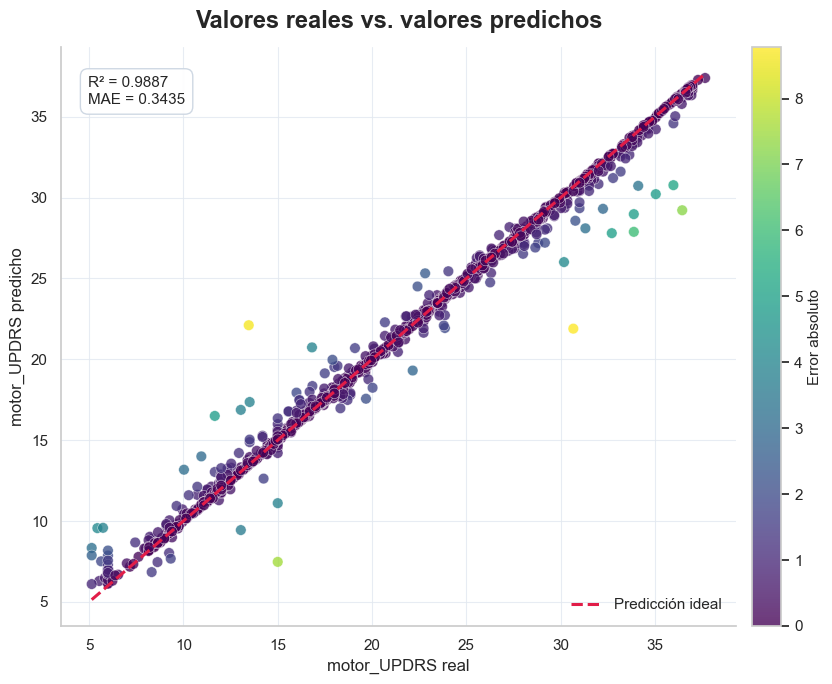

In [194]:
limite_minimo = min(y_test.min(), y_pred.min())
limite_maximo = max(y_test.max(), y_pred.max())

fig, ax = plt.subplots(figsize=(9, 7))

puntos = ax.scatter(
    y_test,
    y_pred,
    c=error_absoluto,
    cmap="viridis",
    s=58,
    alpha=0.78,
    edgecolors="white",
    linewidth=0.35
)

ax.plot(
    [limite_minimo, limite_maximo],
    [limite_minimo, limite_maximo],
    color="#E11D48",
    linewidth=2.2,
    linestyle="--",
    label="Predicción ideal"
)

ax.text(
    0.04,
    0.95,
    f"R² = {r2_final:.4f}\nMAE = {mae_final:.4f}",
    transform=ax.transAxes,
    va="top",
    fontsize=11,
    bbox={"boxstyle": "round,pad=0.5", "facecolor": "white", "alpha": 0.92,
          "edgecolor": "#CBD5E1"}
)

barra_color = fig.colorbar(puntos, ax=ax, pad=0.02)
barra_color.set_label("Error absoluto", fontsize=11)

ax.set_title("Valores reales vs. valores predichos", fontsize=17, weight="bold", pad=14)
ax.set_xlabel("motor_UPDRS real", fontsize=12)
ax.set_ylabel("motor_UPDRS predicho", fontsize=12)
ax.legend(frameon=False, loc="lower right")
ax.grid(True, color="#E2E8F0", linewidth=0.8, alpha=0.8)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

La mayoría de los puntos se concentra cerca de la línea ideal, de acuerdo con el R² final de 0.9887. El rango medio presenta el menor MAE (0.2341), mientras que los valores bajos y altos alcanzan aproximadamente 0.44. Las sobreestimaciones y subestimaciones aparecen en cantidades casi iguales.

## Gráfica de residuos

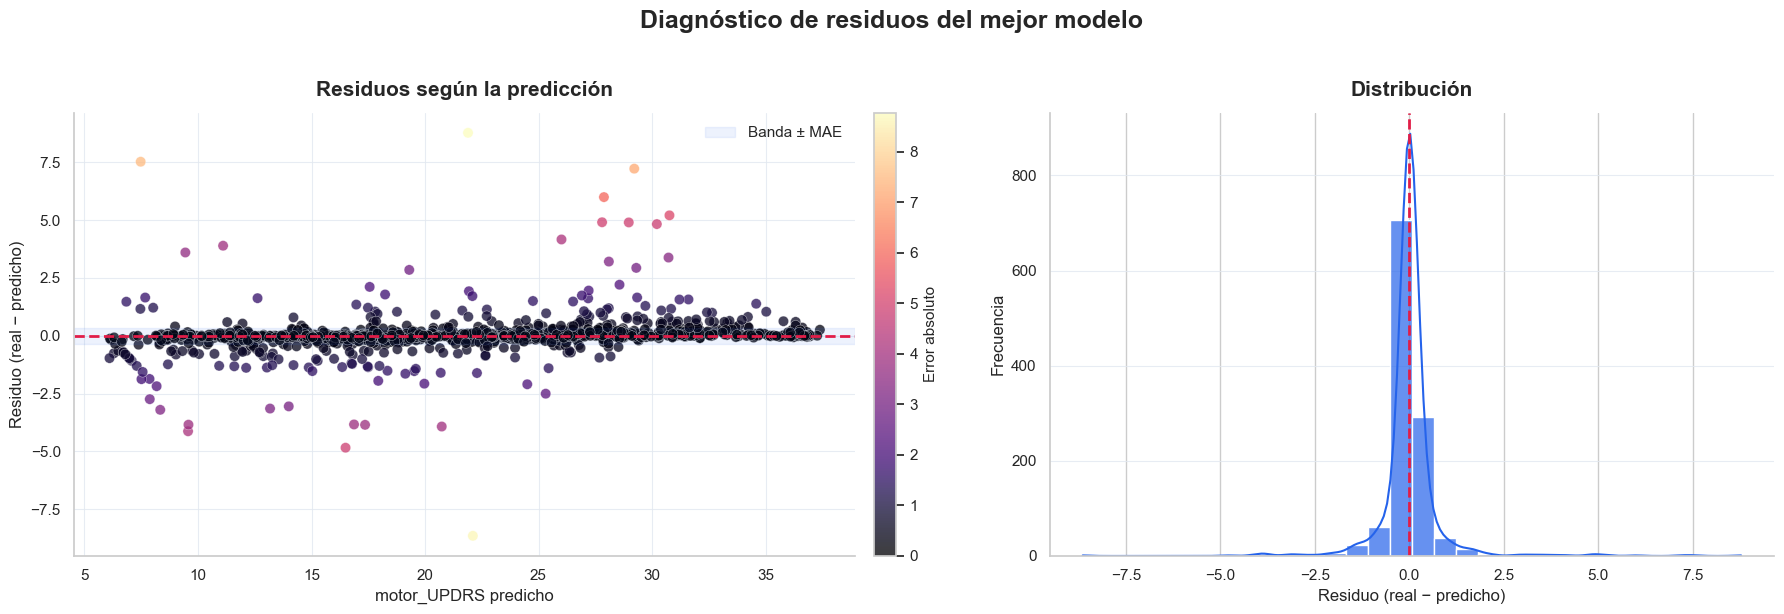

In [196]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 6),
    gridspec_kw={"width_ratios": [1.3, 1]}
)

residuos_plot = axes[0].scatter(
    y_pred,
    residuos,
    c=error_absoluto,
    cmap="magma",
    s=55,
    alpha=0.76,
    edgecolors="white",
    linewidth=0.3
)
axes[0].axhspan(
    -mae_final,
    mae_final,
    color="#2563EB",
    alpha=0.08,
    label="Banda ± MAE"
)
axes[0].axhline(0, color="#E11D48", linewidth=2, linestyle="--")
axes[0].set_title("Residuos según la predicción", fontsize=15, weight="bold", pad=12)
axes[0].set_xlabel("motor_UPDRS predicho", fontsize=12)
axes[0].set_ylabel("Residuo (real − predicho)", fontsize=12)
axes[0].grid(True, color="#E2E8F0", linewidth=0.8, alpha=0.8)
axes[0].legend(frameon=False, loc="upper right")

sns.histplot(
    x=residuos,
    bins=30,
    kde=True,
    color="#2563EB",
    alpha=0.70,
    ax=axes[1]
)
axes[1].axvline(0, color="#E11D48", linewidth=2, linestyle="--")
axes[1].set_title("Distribución", fontsize=15, weight="bold", pad=12)
axes[1].set_xlabel("Residuo (real − predicho)", fontsize=12)
axes[1].set_ylabel("Frecuencia", fontsize=12)
axes[1].grid(True, axis="y", color="#E2E8F0", linewidth=0.8, alpha=0.8)

barra_residuos = fig.colorbar(residuos_plot, ax=axes[0], pad=0.02)
barra_residuos.set_label("Error absoluto", fontsize=11)

sns.despine(ax=axes[0])
sns.despine(ax=axes[1])

fig.suptitle("Diagnóstico de residuos del mejor modelo", fontsize=18, weight="bold", y=1.02)
fig.tight_layout()
plt.show()

Los residuos se concentran alrededor de cero y su media es 0.0181, por lo que no existe un sesgo global importante. La relación entre predicción y error absoluto es casi nula (−0.0354). Se detectan 40 residuos extremos y un error máximo de 8.7750, concentrados en casos poco frecuentes.

# Entrenamiento y almacenamiento del modelo final

Extra Trees se vuelve a entrenar con todos los registros y se guarda junto con la selección de columnas y la imputación.

In [198]:
from sklearn.compose import ColumnTransformer
import joblib

seleccion_columnas = ColumnTransformer(
    [("seleccion", "passthrough", caracteristicas_seleccionadas)],
    remainder="drop"
)

pipeline_final = Pipeline([
    ("seleccion", seleccion_columnas),
    ("imputer", SimpleImputer(strategy="median")),
    ("modelo", ExtraTreesRegressor(n_estimators=500, random_state=42))
])

pipeline_final.fit(X, y)

archivo_modelo = "pipeline_extra_trees_final.joblib"
joblib.dump(pipeline_final, archivo_modelo, compress=3)

print("Modelo entrenado con", len(X), "registros")
print("Archivo guardado:", archivo_modelo)

Modelo entrenado con 5875 registros
Archivo guardado: pipeline_extra_trees_final.joblib


## Comprobación del archivo guardado

In [200]:
pipeline_cargado = joblib.load(archivo_modelo)
prediccion_comprobacion = pipeline_cargado.predict(X.iloc[[0]])[0]

print("Predicción generada:", round(prediccion_comprobacion, 4))
print("Valor real:", round(y.iloc[0], 4))

Predicción generada: 28.199
Valor real: 28.199


# Conclusiones y reflexión crítica

El dataset no presentó duplicados ni nulos originales; los nulos generados en variables descartadas se trataron con la mediana. No fue necesaria una codificación adicional y el escalado resultó importante para MLP y PCA. La combinación manual de `age`, `sex`, `test_time`, `Jitter(%)`, `Jitter(Abs)` y `DFA` ofreció el mejor equilibrio entre desempeño y estabilidad. PCA redujo el rendimiento, mientras Extra Trees fue el mejor modelo con R² medio de 0.9899 y R² final de 0.9887. Los residuos muestran poco sesgo, aunque existen casos extremos. Como limitación, hay mediciones repetidas por paciente; una mejora futura sería validar por sujeto y con datos clínicos externos.